# Task 1

## 1) Data retrieval and collection

In [28]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#load dataset

import pandas as pd

data = pd.read_csv("Salary_Data.csv")
experience=data['YearsExperience'].values
salary=data['Salary'].values

In [5]:
#Display basic information (shape, column names)

print("Experience shape",experience.shape)
print("Shape of dataset:",data.shape)

print("Columns:",data.columns.tolist())

Experience shape (30,)
Shape of dataset: (30, 2)
Columns: ['YearsExperience', 'Salary']


## 2) Data cleaning

In [6]:
print(data.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


There are no missing values

If there were any missing values, it can be either dropped or filled with it's mean or median( for numerical) and mode(for categorical)

data=data.dropna()

data.fillna(data.mean(),inplace=True)

In [7]:
#verify data types

print(data.dtypes)

YearsExperience    float64
Salary               int64
dtype: object


In [25]:
#scaling data

from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

experience_scaled = x_scaler.fit_transform(
    experience.reshape(-1,1)
)

salary_scaled = y_scaler.fit_transform(
    salary.reshape(-1,1)
)

salary_scaled = salary_scaled.reshape(-1)


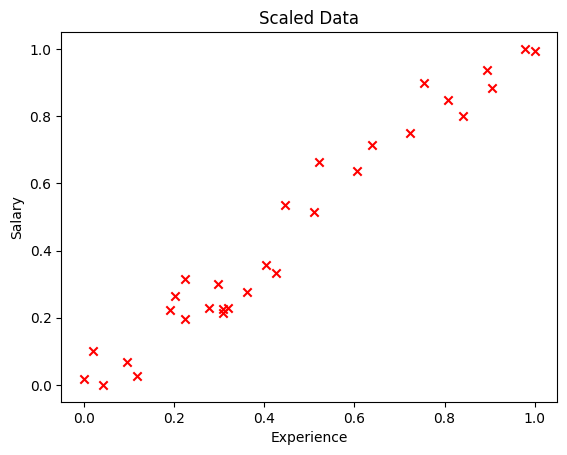

In [27]:
#visualize

plt.scatter(
    experience_scaled,
    salary_scaled,
    marker='x',
    color='red'
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Scaled Data")
plt.show()


## 3) Feature Deisgn

In [29]:
X_scaled = np.column_stack(
    (
        np.ones(len(experience_scaled)),
        experience_scaled.flatten()
    )
)

y_scaled = salary_scaled

print(X_scaled.shape)
print(y_scaled.shape)

(30, 2)
(30,)


so first we add a column of 1's so that the model xan learn the intercept and without it, model will be forced to pass through (0,0)

## 4) Algorithm selection

WE CHOOSE LINEAR REGRESSION

Linear regression uses:
ŷ = θ₀ + θ₁x

where
 x= YearsExperience
 ŷ= predicted salary
 θ₀= intercept
 θ₁= slope

 Here we have to predict continuous numerical value i.e salary from YearsEcperience as the input feature which makes this a regression problem. As per the visualization above, it seems that the YearsExperience and ppredicted salary have linear relationship. So linear redression is used.


## 5) Loss function selection

### MSE

It measures the average sqaured difference between the actual salary values and predicted salary values. It is used by default in linear regression

MSE = (1/n) Σ(i=1 to n) (yᵢ - ŷᵢ)²

A lower MSE indicates that the model is making more accurate decisions. Squaring the errors means larger mistakes recieve greater penalty. This helps the model to learn more accurate predictions.




In [30]:
def compute_cost(X, y, theta):

    predictions = np.matmul(X, theta)

    errors = predictions - y

    return np.sum(errors**2)/(2*len(y))

In [31]:
theta = np.zeros(2)

initial_cost = compute_cost(
    X_scaled,
    y_scaled,
    theta
)

print("Initial Cost:", initial_cost)

Initial Cost: 0.15286373365038744


initial cost is the value of loss function before training starts

## 6) Model Training


### Gradient descent

It is used to find best values of model parameters by minimizing cost function

At each iteartion, it calculates error,updates parameters to reduce cost

Parameters

alpha = learning rate (step size)

iterations = number of updates

theta = model parameters

X = feature matrix

y = target values

In [32]:
def gradient_descent(X, y, alpha, iterations):

    theta = np.zeros(2)

    m = len(y)

    for _ in range(iterations):

        predictions = np.dot(X, theta)

        errors = predictions - y

        t0 = theta[0] - (alpha/m) * np.sum(errors)

        t1 = theta[1] - (alpha/m) * np.sum(
            errors * X[:,1]
        )

        theta = np.array([t0, t1])

    return theta

In [33]:
iterations = 50000
alpha = 0.001

theta = gradient_descent(
    X_scaled,
    y_scaled,
    alpha,
    iterations
)

print("Theta:", theta)

print(
    "Final Cost:",
    compute_cost(
        X_scaled,
        y_scaled,
        theta
    )
)

Theta: [-0.00714777  1.0263057 ]
Final Cost: 0.002205014178641856


In [41]:
print("Intercept:", theta[0])
print("Coefficient:", theta[1])

Intercept: -0.007147773619442344
Coefficient: 1.0263056979639966


intercept=theta[0]

coefficient=theta[1]

coefficient(slope) indicates strength and direction of reln betn YearsExperience and Salary

intercept indicates predicted salary when YearsExperience is 0

the coefficient is positive so it indicates that salary inreases as experience increases

In [34]:
def predict_single(x, theta, x_scaler, y_scaler):

    x_scaled = x_scaler.transform([[x]])

    y_scaled = theta[1] * x_scaled + theta[0]

    y = y_scaler.inverse_transform(y_scaled)

    return y[0][0]

In [35]:
def predict_batch(X, theta, x_scaler, y_scaler):

    X = np.array(X).reshape(-1,1)

    X_scaled = x_scaler.transform(X)

    y_scaled = theta[1] * X_scaled + theta[0]

    y = y_scaler.inverse_transform(y_scaled)

    return y.flatten()

## 7) Model evaluation

In [ ]:
pred_salary = predict_batch(
    experience,
    theta,
    x_scaler,
    y_scaler
)


MSE = 31608065.041601915


### MSE

In [37]:
mse = np.mean(
    (salary - pred_salary)**2
)

print("MSE =", mse)

MSE = 31608065.041601915


Lower MSE indicates better prediction accuracy

### R^2 score

In [38]:
from sklearn.metrics import r2_score

r2 = r2_score(
    salary,
    pred_salary
)

print("R² Score =", r2)

R² Score = 0.956492639832573


R^2 measures how well model explains variation in salary

Closer the value is to 1, stronger is the fit/

### Regression line visualzation

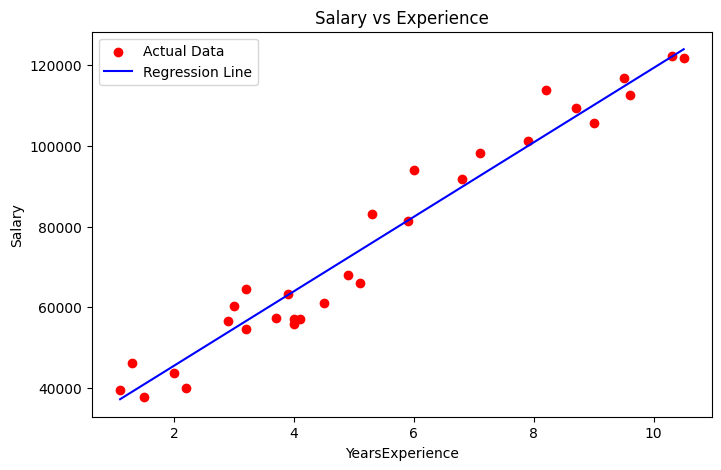

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    experience,
    salary,
    color='red',
    label='Actual Data'
)

sorted_idx = np.argsort(experience)

plt.plot(
    experience[sorted_idx],
    pred_salary[sorted_idx],
    color='blue',
    label='Regression Line'
)

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")

plt.legend()

plt.show()

### Actual vs Predicted visulaization

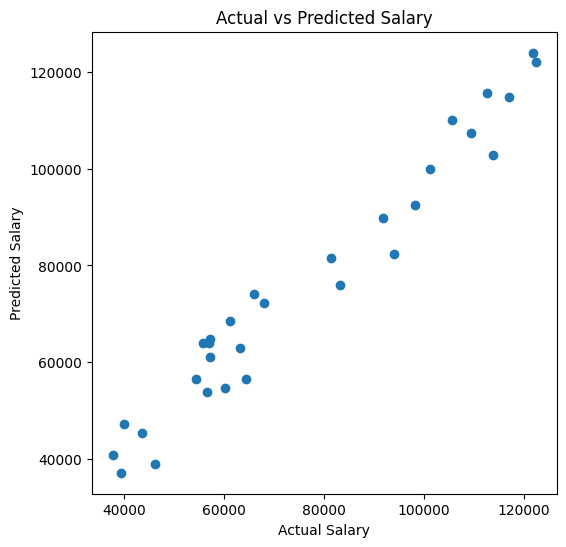

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(
    salary,
    pred_salary
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

## Discussion

Positive relation was seen betn Salary and YearsExperience in scatterplot. So, linear regression was used and gradient descent successfully minimized prediction error.

Regression line shows fitted line mostly close to data points so it is a good fit

The predicted and actual salary are close to eachother indicating model has good accuracy

## Conclusion

A Simple Linear Regression model was developed using YearsExperience to predict Salary. The model was trained using Gradient Descent and evaluated using MSE and R^2 score. The results show that YearsExperience is a useful predictor of Salary and gives good accuracy.